In [1]:
import pandas as pd
import numpy as np
import spacy
import math
import nltk
import matplotlib.pyplot as plt
import gensim.downloader as api
from wordcloud import WordCloud
from spacy.lang.en import English
from string import punctuation
from nltk.corpus import words, stopwords
from textblob import TextBlob
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
wv = api.load("word2vec-google-news-300")

In [3]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kamalrajanisrani/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kamalrajanisrani/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Part 1: Preprocessing Pipeline

## Tokenisation

In [4]:
def tokenise(tickets):
    
    nlp = English()
    data = []
    
    for ticket in tickets:
        doc = nlp(ticket)
        sentence = []
        for token in doc:
            sentence.append(token.text)
        data.append(sentence)

    return data

## Case Folding

In [5]:
def lowercase(data):
    
    for sentence in data:
        for i in range(len(sentence)):
            sentence[i] = sentence[i].lower()
    
    return data

## Punctuation Removal

In [6]:
def remove_punctuation(data):

    list_punc = list(punctuation)

    new_data = []

    for sentence in data:
        new_sentence = []
        for word in sentence:
            if word not in list_punc:
                new_sentence.append(word)
        new_data.append(new_sentence)
        
    return new_data

## Hidden Character Removal

In [7]:
def remove_hidden_characters(data):
    
    for sentence in data:
        for i in range(len(sentence)):
            sentence[i] = sentence[i].replace("\n","")
            sentence[i] = sentence[i].replace("\t","")
            sentence[i] = sentence[i].replace("\'", "")

    return data

## Whitespace Removal

In [8]:
def whitespace_remove(data):
    for sentence in data:
        for i in range(len(sentence)):
            sentence[i] = sentence[i].strip()

    return data

## Stopword Removal

In [9]:
def remove_stopwords(data):
    
    new_data = []
    stop_words = list(stopwords.words('english'))

    for sentence in data:
        new_sentence = []
        for word in sentence:
            if word not in stop_words:
                new_sentence.append(word)
        new_data.append(new_sentence)

    return new_data

## Bringing it all together

In [10]:
def preprocess(tickets):
    
    data = tokenise(tickets)
    data = lowercase(data)
    data = remove_punctuation(data)
    data = remove_hidden_characters(data)
    data = whitespace_remove(data)
    data = remove_stopwords(data)
    
    return data

# Part 2: Encoding

## Word Embedding after spelling correction

In [11]:
def get_embedding(word):

    if word in wv:
        return wv[word]

    word = str(TextBlob(word).correct())

    if word in wv:
        return wv[word]

    return np.random.randn(300) * 0.01
    

## Cosine Similarity
### Getting the cosine similarity of 2 words (vectors)

In [12]:
def get_cosine_similarity(w, l):
    return np.dot(w, l) / (np.linalg.norm(w) * np.linalg.norm(l))

## Most Similar Word
### Most Similar Word in a sentence to a label is the word whose cosine similarity is the maxium with the label.

In [13]:
def find_most_similar_word(sentence, labels):
    
    max_similarity = -np.inf
    label_list = labels.split('_')
    
    for word in sentence:
        word_vec = get_embedding(word)
        
        for label in label_list:
            label_vec = get_embedding(label)

            similarity = get_cosine_similarity(word_vec, label_vec)

            
            if similarity > max_similarity:
                
                max_similarity = similarity
                most_similar_word = word

    return most_similar_word
    

## Label Similarity
### Finding the most similar word present in ticket description which classifies the label using the word2vec word embeddings. If any OOV (out-of-vocab) word found, a random embedding is returned

In [14]:
def label_similarity(data):
    
    for index, sentence in enumerate(data):
    
        similar_word = find_most_similar_word(sentence, labels[index])
        sentence.clear()
        sentence.append(similar_word)

    return data

## Building Vocabulary
### Adding unknown token in the vocabulary to account for any unknown word encountered during inference

In [15]:
def build_vocabulary(data):
    
    vocabulary = {"<UNK>": 0}
    
    for sentence in data:
        for word in sentence:
            if word not in vocabulary:
                vocabulary[word] = len(vocabulary)

    return vocabulary

## Building Dataset

In [16]:
def build_dataset(data, labels, vocabulary):
    
    X = []
    for sentence in data:
        feature_vector = [0] * len(vocabulary)
        for word in sentence:
            feature_vector[vocabulary[word]] = 1
        X.append(feature_vector)

    X = np.array(X)
    encoder = LabelEncoder()
    y = encoder.fit_transform(np.array(labels))
    
    return X, y, encoder

# Part 3: Building a classifier

## Calling all functions - loading raw data, preprocessing, label similarity with sentence and vocabulary building

In [17]:
df = pd.read_csv('cw_data.csv', names=['Ticket Description', 'Classification'])
tickets = df['Ticket Description'].tolist()
labels = df['Classification'].tolist()

data = preprocess(tickets)
data = label_similarity(data)
vocabulary = build_vocabulary(data)

X, y, encoder = build_dataset(data, labels, vocabulary)

## Logistic Regression Classification Model

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
lr_clf = LogisticRegression(random_state=0, C=0.7).fit(X_train, y_train)
y_pred = lr_clf.predict(X_test)

print('Logistic Regression Train Accuracy:', round(accuracy_score(y_train, lr_clf.predict(X_train)), 3))
print('Logistic Regression Test Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print('Logistic Regression Precision:', round(precision_score(y_test, y_pred, average='macro'), 3))
print('Logistic Regression Recall:', round(recall_score(y_test, y_pred, average='macro'), 3))
print('Logistic Regression F1 Score:', round(f1_score(y_test, y_pred, average='macro'),3))

Logistic Regression Train Accuracy: 0.963
Logistic Regression Test Accuracy: 0.946
Logistic Regression Precision: 0.964
Logistic Regression Recall: 0.931
Logistic Regression F1 Score: 0.94


# Appendix

## Word Clouds for each label based on the most similar word from word2vec embeddings

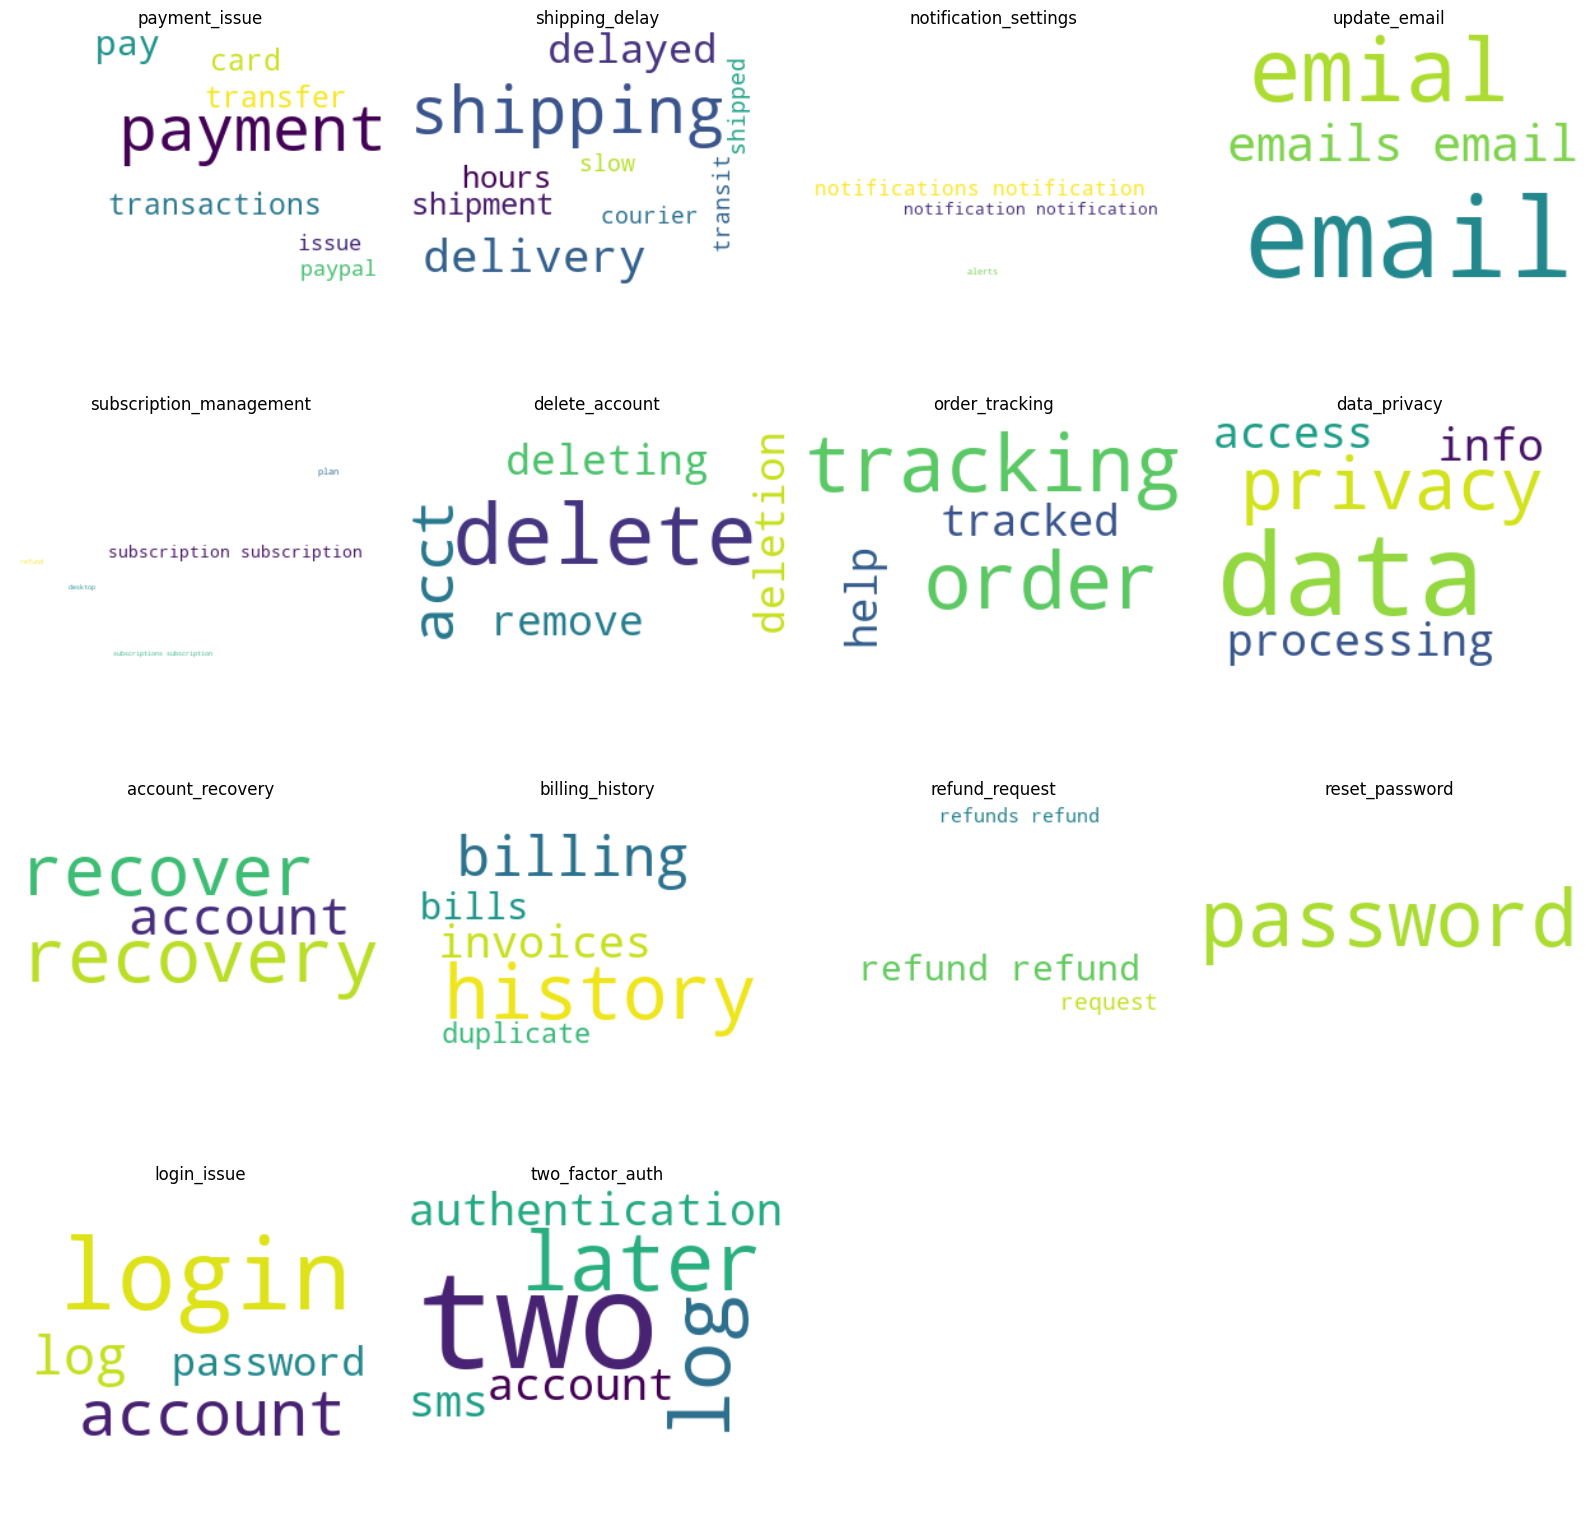

In [19]:
unique_labels = df["Classification"].value_counts().index.tolist()

cols = 4
rows = 4

fig, axes = plt.subplots(rows, cols, figsize=(16, 16))
axes = axes.flatten()

for i, label in enumerate(unique_labels):

    words = []

    for sentence, l in zip(data, labels):
        if l == label:
            words.append(sentence[0])
            
    text = " ".join(words)

    wordcloud = WordCloud(width=300, height=200, background_color="white", colormap="viridis").generate(text)
    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(label)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Confusion Matrix of Training Data

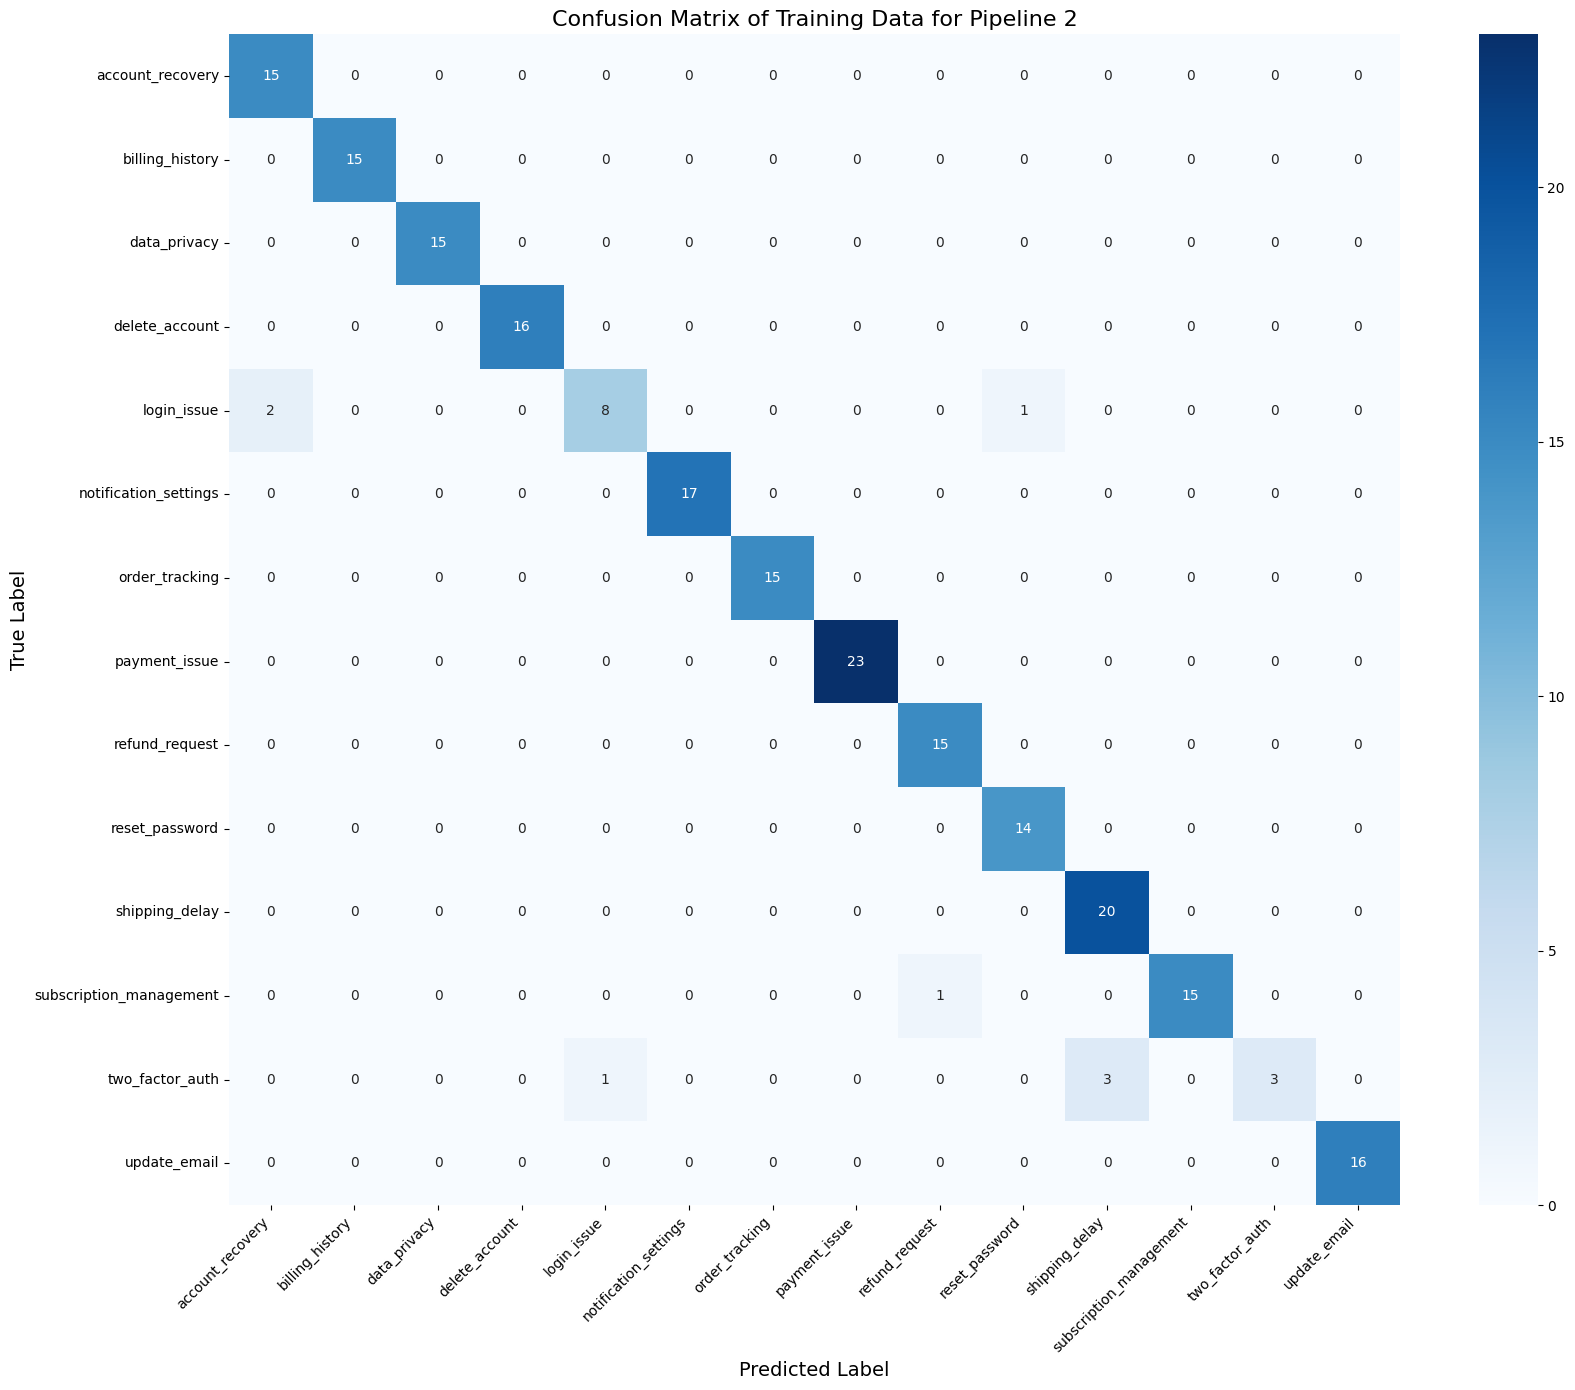

In [20]:
cm = confusion_matrix(y_train, lr_clf.predict(X_train))
class_names = encoder.inverse_transform(lr_clf.classes_)

plt.figure(figsize=(18, 14))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, square=True, cbar=True)

plt.xticks(rotation=45, ha='right')

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix of Training Data for Pipeline 2", fontsize=16)

plt.tight_layout()
plt.show()

## Confusion Matrix of Test Data

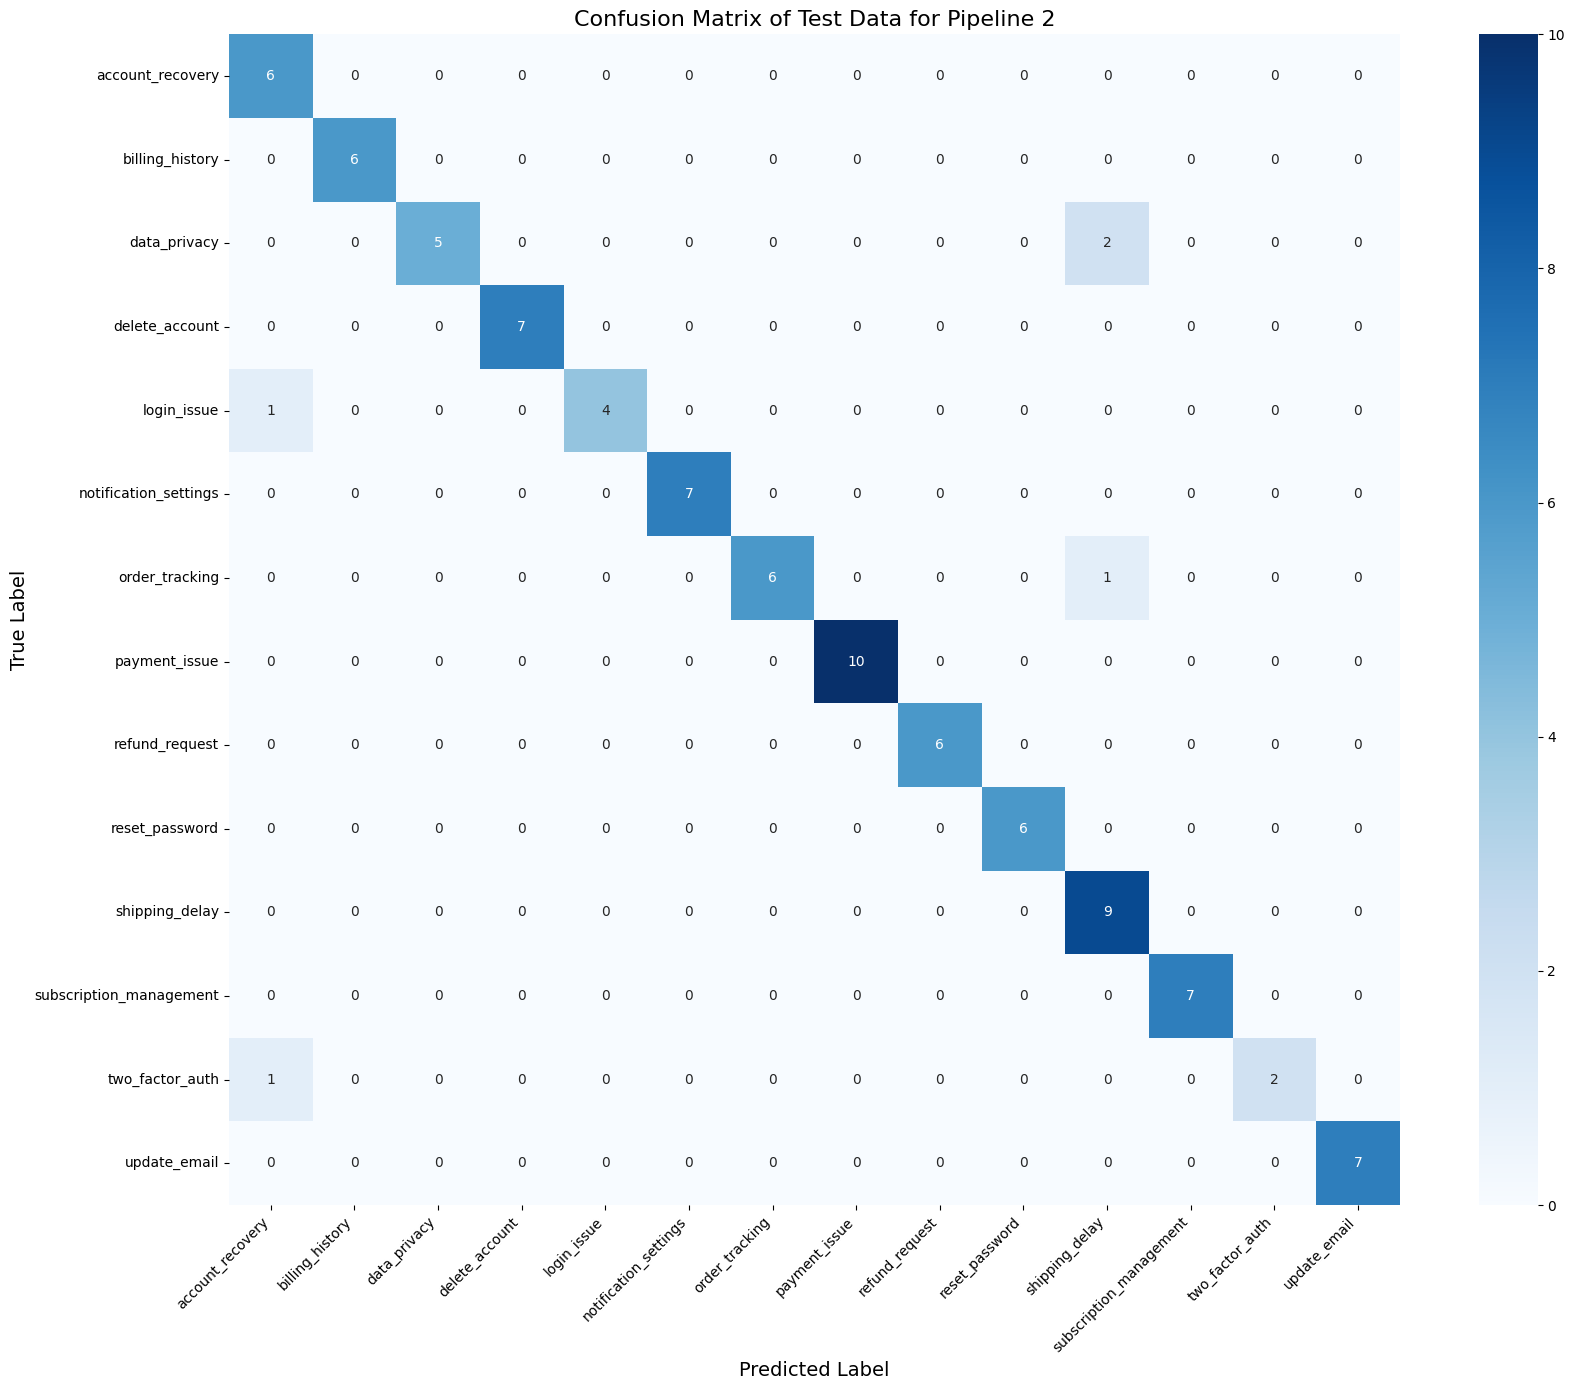

In [21]:
cm = confusion_matrix(y_test, y_pred)
class_names = encoder.inverse_transform(lr_clf.classes_)

plt.figure(figsize=(18, 14))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, square=True, cbar=True)

plt.xticks(rotation=45, ha='right')

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix of Test Data for Pipeline 2", fontsize=16)

plt.tight_layout()
plt.show()

## Results of most similar word for each sentence using word2vec embeddings

In [22]:
for index, sentence in enumerate(data):
    print(index, sentence, labels[index])

0 ['shipped'] shipping_delay
1 ['tracked'] order_tracking
2 ['email'] update_email
3 ['recover'] account_recovery
4 ['emial'] update_email
5 ['email'] update_email
6 ['recover'] account_recovery
7 ['shipping'] shipping_delay
8 ['bills'] billing_history
9 ['data'] data_privacy
10 ['payment'] payment_issue
11 ['orders'] order_tracking
12 ['password'] reset_password
13 ['duplicate'] billing_history
14 ['subscription'] subscription_management
15 ['history'] billing_history
16 ['history'] billing_history
17 ['history'] billing_history
18 ['acct'] delete_account
19 ['payment'] payment_issue
20 ['processing'] data_privacy
21 ['data'] data_privacy
22 ['tracking'] order_tracking
23 ['recovery'] account_recovery
24 ['refund'] refund_request
25 ['refund'] refund_request
26 ['billing'] billing_history
27 ['data'] data_privacy
28 ['payment'] payment_issue
29 ['delete'] delete_account
30 ['recovery'] account_recovery
31 ['data'] data_privacy
32 ['delete'] delete_account
33 ['email'] update_email
34 